<a href="https://colab.research.google.com/github/epleywin/ECON3916-Statistical-Machine-Learning/blob/main/Assignment%201/%20Econ_3916_Assignment_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
student_basket = [
    {'Item': 'Tuition', 'Price_2016': 45000, 'Price_2024': 58000},
    {'Item': 'Rent (1 Bed)', 'Price_2016': 1200, 'Price_2024': 1800},
    {'Item': 'Chipotle Burrito', 'Price_2016': 7.50, 'Price_2024': 11.50},
    {'Item': 'Netflix', 'Price_2016': 9.99, 'Price_2024': 17.99}
]

In [2]:
def calculate_inflation(base, current):
    return ((current - base) / base) * 100

for item in student_basket:
    rate = calculate_inflation(item['Price_2016'], item['Price_2024'])
    print(f"{item['Item']}: {rate:.2f}% Inflation")

Tuition: 28.89% Inflation
Rent (1 Bed): 50.00% Inflation
Chipotle Burrito: 53.33% Inflation
Netflix: 80.08% Inflation


In [3]:
!pip install fredapi
from fredapi import Fred
fred = Fred(api_key='c8f9a52db41da22f7e01421912f70965')

# Fetch Series
official_cpi = fred.get_series('CPIAUCSL')
tuition = fred.get_series('CUSR0000SEEB')
rent = fred.get_series('CUSR0000SEHA')
netflix = fred.get_series('CUSR0000SERA02')
chipotle_burrito = fred.get_series('CUSR0000SEFV')

In [4]:
def normalize(series):
    series_2016 = series[series.index.year == 2016]
    if len(series_2016) > 0:
        base_value = series_2016.mean()
        return (series / base_value) * 100
    else:
        return (series / series.iloc[0]) * 100

official_cpi = normalize(official_cpi)
tuition = normalize(tuition)
rent = normalize(rent)
netflix = normalize(netflix)
chipotle_burrito = normalize(chipotle_burrito)

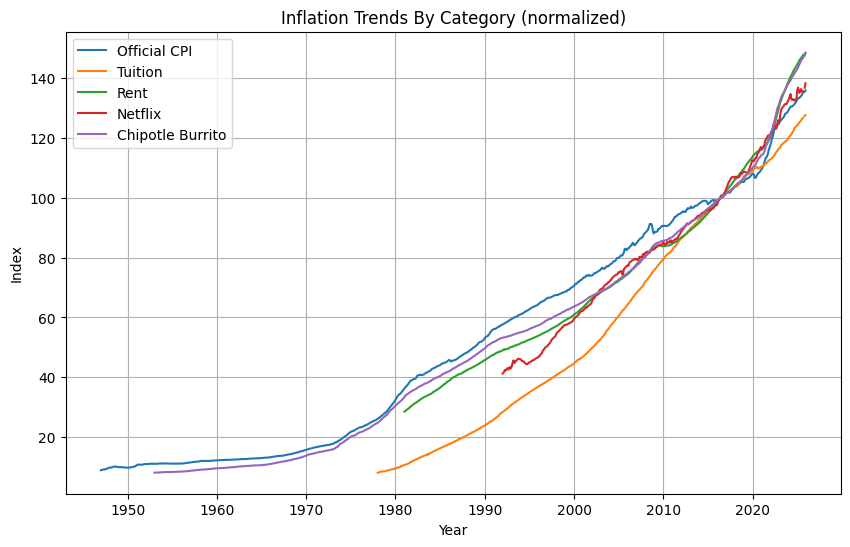

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(official_cpi, label='Official CPI')
plt.plot(tuition, label='Tuition')
plt.plot(rent, label='Rent')
plt.plot(netflix, label='Netflix')
plt.plot(chipotle_burrito, label='Chipotle Burrito')

plt.xlabel('Year')
plt.ylabel('Index')
plt.title('Inflation Trends By Category (normalized)')
plt.legend()
plt.grid(True)
plt.show()

In [6]:
import pandas as pd

df = pd.DataFrame({
    'Official_CPI': official_cpi,
    'Tuition': tuition,
    'Rent': rent,
    'Netflix': netflix,
    'Burritos': chipotle_burrito
})

df = df.dropna()


weighting = {
    'Tuition': 0.4,
    'Rent': 0.3,
    'Netflix': 0.1,
    'Burritos': 0.2,
}


In [7]:
df['Student_SPI'] = (
    weighting['Tuition'] * df['Tuition'] +
    weighting['Rent'] * df['Rent'] +
    weighting['Netflix'] * df['Netflix'] +
    weighting['Burritos'] * df['Burritos']
)

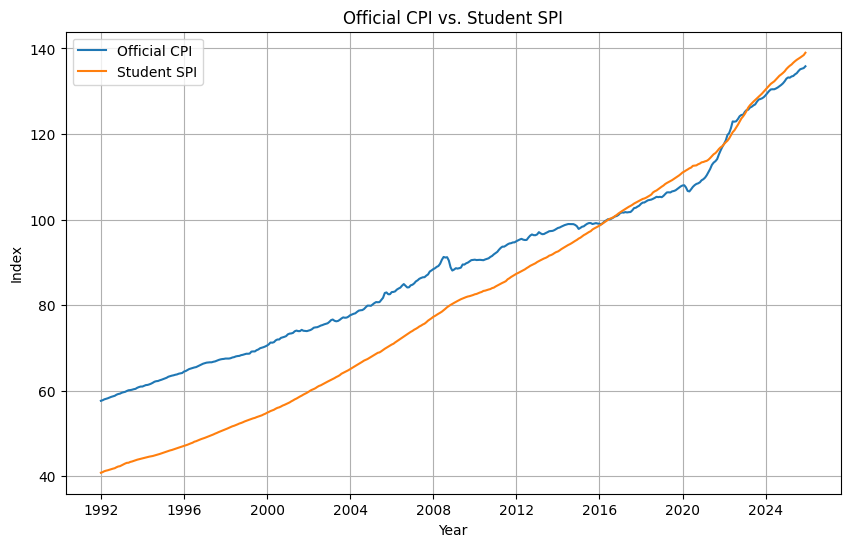

In [8]:
plt.figure(figsize=(10,6))

plt.plot(df.index, df['Official_CPI'], label='Official CPI')
plt.plot(df.index, df['Student_SPI'], label='Student SPI')

plt.xlabel('Year')
plt.ylabel('Index')
plt.title('Official CPI vs. Student SPI')
plt.legend()
plt.grid(True)
plt.show()

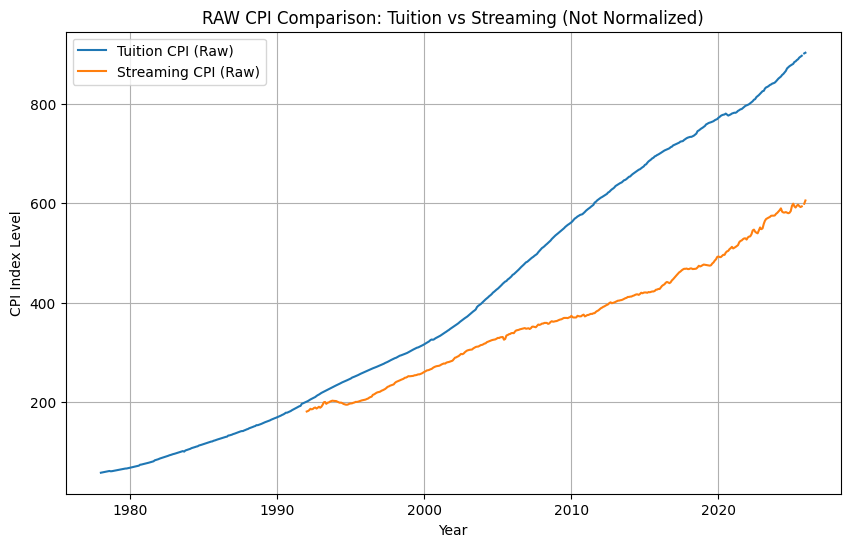

In [11]:
import matplotlib.pyplot as plt

tuition_raw = fred.get_series('CUSR0000SEEB')
streaming_raw = fred.get_series('CUSR0000SERA02')

plt.figure(figsize=(10,6))

plt.plot(tuition_raw, label='Tuition CPI (Raw)')
plt.plot(streaming_raw, label='Streaming CPI (Raw)')

plt.xlabel('Year')
plt.ylabel('CPI Index Level')
plt.title('RAW CPI Comparison: Tuition vs Streaming (Not Normalized)')
plt.legend()
plt.grid(True)

plt.show()

Tuition: 28.89% Inflation
Rent (1 Bed): 50.00% Inflation
Chipotle Burrito: 53.33% Inflation
Netflix: 80.08% Inflation


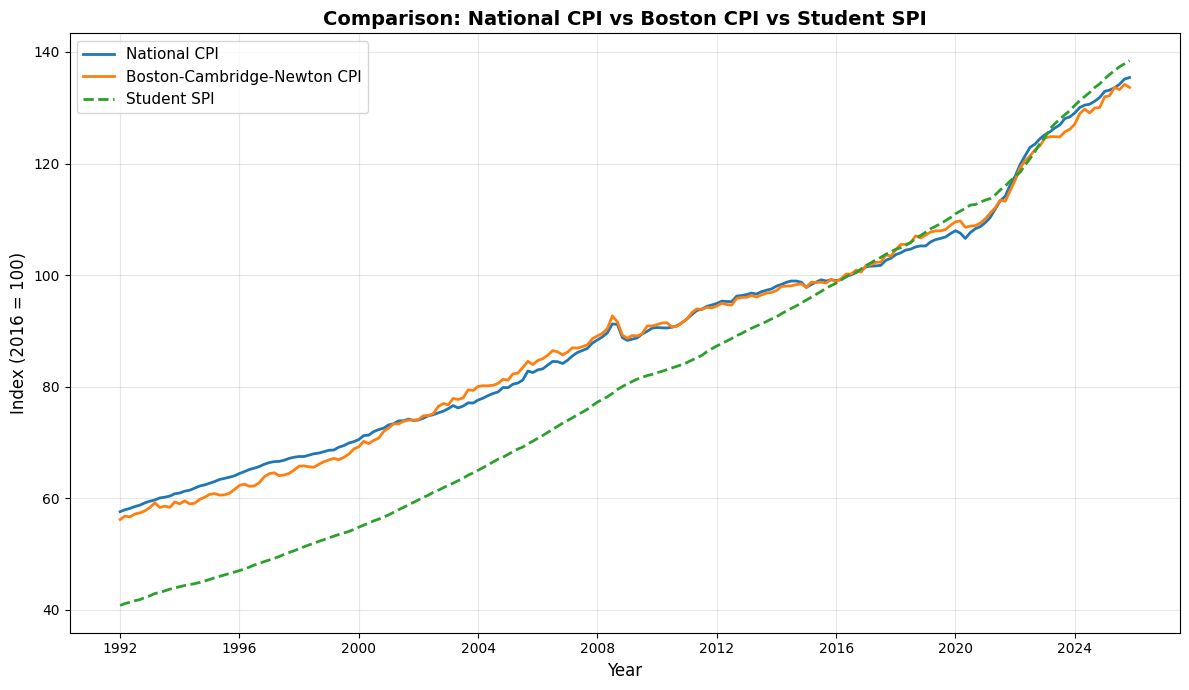


=== Summary Statistics (Latest Values) ===
National CPI (Latest): 135.43
Boston CPI (Latest): 133.66
Student SPI (Latest): 138.46

Boston vs National Difference: -1.77 points
Student vs National Difference: 3.03 points


In [10]:
# Your existing student basket calculation
student_basket = [
    {'Item': 'Tuition', 'Price_2016': 45000, 'Price_2024': 58000},
    {'Item': 'Rent (1 Bed)', 'Price_2016': 1200, 'Price_2024': 1800},
    {'Item': 'Chipotle Burrito', 'Price_2016': 7.50, 'Price_2024': 11.50},
    {'Item': 'Netflix', 'Price_2016': 9.99, 'Price_2024': 17.99}
]

def calculate_inflation(base, current):
    return ((current - base) / base) * 100

for item in student_basket:
    rate = calculate_inflation(item['Price_2016'], item['Price_2024'])
    print(f"{item['Item']}: {rate:.2f}% Inflation")

# Install and import FRED API
!pip install fredapi
from fredapi import Fred
import pandas as pd
import matplotlib.pyplot as plt

# Initialize FRED API
fred = Fred(api_key='c8f9a52db41da22f7e01421912f70965')

# Fetch National CPI and component series
official_cpi = fred.get_series('CPIAUCSL')
tuition = fred.get_series('CUSR0000SEEB')
rent = fred.get_series('CUSR0000SEHA')
netflix = fred.get_series('CUSR0000SERA02')
chipotle_burrito = fred.get_series('CUSR0000SEFV')

# Fetch Boston-Cambridge-Newton CPI
boston_cpi = fred.get_series('CUURA103SA0')

# Normalize function to base year 2016
def normalize_to_2016(series):
    # Filter to get 2016 values
    series_2016 = series[series.index.year == 2016]
    if len(series_2016) > 0:
        base_value = series_2016.mean()  # Average of 2016 values
        return (series / base_value) * 100
    else:
        return (series / series.iloc[0]) * 100

# Normalize all series to 2016 = 100
official_cpi_norm = normalize_to_2016(official_cpi)
boston_cpi_norm = normalize_to_2016(boston_cpi)
tuition_norm = normalize_to_2016(tuition)
rent_norm = normalize_to_2016(rent)
netflix_norm = normalize_to_2016(netflix)
chipotle_norm = normalize_to_2016(chipotle_burrito)

# Create Student SPI
df = pd.DataFrame({
    'Official_CPI': official_cpi_norm,
    'Boston_CPI': boston_cpi_norm,
    'Tuition': tuition_norm,
    'Rent': rent_norm,
    'Netflix': netflix_norm,
    'Burritos': chipotle_norm
})

df = df.dropna()

# Define weightings for Student SPI
weighting = {
    'Tuition': 0.4,
    'Rent': 0.3,
    'Netflix': 0.1,
    'Burritos': 0.2,
}

# Calculate Student SPI
df['Student_SPI'] = (
    weighting['Tuition'] * df['Tuition'] +
    weighting['Rent'] * df['Rent'] +
    weighting['Netflix'] * df['Netflix'] +
    weighting['Burritos'] * df['Burritos']
)

# Plot all three series: National CPI, Boston CPI, and Student SPI
plt.figure(figsize=(12, 7))
plt.plot(df.index, df['Official_CPI'], label='National CPI', linewidth=2)
plt.plot(df.index, df['Boston_CPI'], label='Boston-Cambridge-Newton CPI', linewidth=2)
plt.plot(df.index, df['Student_SPI'], label='Student SPI', linewidth=2, linestyle='--')

plt.xlabel('Year', fontsize=12)
plt.ylabel('Index (2016 = 100)', fontsize=12)
plt.title('Comparison: National CPI vs Boston CPI vs Student SPI', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print summary statistics
print("\n=== Summary Statistics (Latest Values) ===")
print(f"National CPI (Latest): {df['Official_CPI'].iloc[-1]:.2f}")
print(f"Boston CPI (Latest): {df['Boston_CPI'].iloc[-1]:.2f}")
print(f"Student SPI (Latest): {df['Student_SPI'].iloc[-1]:.2f}")
print(f"\nBoston vs National Difference: {df['Boston_CPI'].iloc[-1] - df['Official_CPI'].iloc[-1]:.2f} points")
print(f"Student vs National Difference: {df['Student_SPI'].iloc[-1] - df['Official_CPI'].iloc[-1]:.2f} points")